# Introduction to Data Science 2025

# Week 2

## Exercise 1 | Titanic: data preprocessing and imputation
<span style="font-weight: bold"> *Note: You can find tutorials for NumPy and Pandas under 'Useful tutorials' in the course material.*</span>

Download the [Titanic dataset](https://www.kaggle.com/c/titanic) [train.csv] from Kaggle or <span style="font-weight: 500">directly from the course material</span>, and complete the following exercises. If you choose to download the dataset from Kaggle, you will need to create a Kaggle account unless you already have one, but it is quite straightforward.

The dataset consists of personal information of all the passengers on board the RMS Titanic, along with information about whether they survived the iceberg collision or not.

1. Your first task is to read the data file and print the shape of the data.

    <span style="font-weight: 500"> *Hint 1: You can read them into a Pandas dataframe if you wish.*</span>
    
    <span style="font-weight: 500"> *Hint 2: The shape of the data should be (891, 12).*</span>

In [1]:
import pandas as pd

df=pd.read_csv('train.csv')

print(df.shape)

(891, 12)


2. Let's look at the data and get started with some preprocessing. Some of the columns, e.g <span style="font-weight: 500"> *Name*</span>, simply identify a person and are not useful for prediction tasks. Try to identify these columns, and remove them.

    <span style="font-weight: 500"> *Hint: The shape of the data should now be (891, 9).*</span>

In [2]:
df=df.drop(["PassengerId","Name","Ticket"],axis=1)

print(df.shape)

print(df.head())

(891, 9)
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Cabin Embarked
0         0       3    male  22.0      1      0   7.2500   NaN        S
1         1       1  female  38.0      1      0  71.2833   C85        C
2         1       3  female  26.0      0      0   7.9250   NaN        S
3         1       1  female  35.0      1      0  53.1000  C123        S
4         0       3    male  35.0      0      0   8.0500   NaN        S


3. The column <span style="font-weight: 500">*Cabin*</span> contains a letter and a number. A smart catch at this point would be to notice that the letter stands for the deck level on the ship. Keeping just the deck information would be more informative when developing, e.g. a classifier that predicts whether a passenger survived. The next step in our preprocessing will be to add a new column to the dataset, which consists simply of the deck letter. You can then remove the original <span style="font-weight: 500">*Cabin*</span>-column.

<span style="font-weight: 500">*Hint: The deck letters should be ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'T'].*</span>

In [3]:
df['Deck']=df['Cabin'].str[0]

df=df.drop('Cabin',axis=1)

print(df.head(20))

    Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked Deck
0          0       3    male  22.0      1      0   7.2500        S  NaN
1          1       1  female  38.0      1      0  71.2833        C    C
2          1       3  female  26.0      0      0   7.9250        S  NaN
3          1       1  female  35.0      1      0  53.1000        S    C
4          0       3    male  35.0      0      0   8.0500        S  NaN
5          0       3    male   NaN      0      0   8.4583        Q  NaN
6          0       1    male  54.0      0      0  51.8625        S    E
7          0       3    male   2.0      3      1  21.0750        S  NaN
8          1       3  female  27.0      0      2  11.1333        S  NaN
9          1       2  female  14.0      1      0  30.0708        C  NaN
10         1       3  female   4.0      1      1  16.7000        S    G
11         1       1  female  58.0      0      0  26.5500        S    C
12         0       3    male  20.0      0      0   8.0500       

4. You’ll notice that some of the columns, such as the previously added deck number, are [categorical](https://en.wikipedia.org/wiki/Categorical_variable). To preprocess the categorical variables so that they're ready for further computation, we need to avoid the current string format of the values. This means the next step for each categorical variable is to transform the string values to numeric ones, that correspond to a unique integer ID representative of each distinct category. This process is called label encoding and you can read more about it [here](https://pandas.pydata.org/docs/user_guide/categorical.html).

    <span style="font-weight: 500">*Hint: Pandas can do this for you.*</span>

In [ ]:
categorical_columns=['Sex','Embarked','Deck']

#label encoding part: (i think)
# sex: 1=m, 0=f, 
# embarked: 0=C, 1=Q, 2=S, 
# deck: A=0, B=1, C=2, D=3, E=4, F=5, G=6, T=7, NaN=-1)
for col in categorical_columns:
    df[col]=df[col].astype('category').cat.codes

print(df.head(20))

    Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  Deck
0          0       3    1  22.0      1      0   7.2500         2    -1
1          1       1    0  38.0      1      0  71.2833         0     2
2          1       3    0  26.0      0      0   7.9250         2    -1
3          1       1    0  35.0      1      0  53.1000         2     2
4          0       3    1  35.0      0      0   8.0500         2    -1
5          0       3    1   NaN      0      0   8.4583         1    -1
6          0       1    1  54.0      0      0  51.8625         2     4
7          0       3    1   2.0      3      1  21.0750         2    -1
8          1       3    0  27.0      0      2  11.1333         2    -1
9          1       2    0  14.0      1      0  30.0708         0    -1
10         1       3    0   4.0      1      1  16.7000         2     6
11         1       1    0  58.0      0      0  26.5500         2     2
12         0       3    1  20.0      0      0   8.0500         2    -1
13    

5. Next, let's look into missing value **imputation**. Some of the rows in the data have missing values, e.g when the cabin number of a person is unknown. Most machine learning algorithms have trouble with missing values, and they need to be handled during preprocessing:

    a) For continuous variables, replace the missing values with the mean of the non-missing values of that column.

    b) For categorical variables, replace the missing values with the mode of the column.

    <span style="font-weight: 500">*Remember: Even though in the previous step we transformed categorical variables into their numeric representation, they are still categorical.*</span>

In [16]:
continuous=['Age','Fare']
categorical=['Sex', 'Embarked', 'Deck'] 

for col in continuous:
    df[col].fillna(df[col].mean(), inplace=True)

for col in categorical:
    df[col].fillna(df[col].mode()[0], inplace=True)

print(df.head(20))

    Survived  Pclass  Sex        Age  SibSp  Parch     Fare  Embarked  Deck
0          0       3    1  22.000000      1      0   7.2500         2    -1
1          1       1    0  38.000000      1      0  71.2833         0     2
2          1       3    0  26.000000      0      0   7.9250         2    -1
3          1       1    0  35.000000      1      0  53.1000         2     2
4          0       3    1  35.000000      0      0   8.0500         2    -1
5          0       3    1  29.699118      0      0   8.4583         1    -1
6          0       1    1  54.000000      0      0  51.8625         2     4
7          0       3    1   2.000000      3      1  21.0750         2    -1
8          1       3    0  27.000000      0      2  11.1333         2    -1
9          1       2    0  14.000000      1      0  30.0708         0    -1
10         1       3    0   4.000000      1      1  16.7000         2     6
11         1       1    0  58.000000      0      0  26.5500         2     2
12         0

C:\Users\nikip\AppData\Local\Temp\ipykernel_14688\2022548574.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\nikip\AppData\Local\Temp\ipykernel_14688\2022548574.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

6. At this point, all data is numeric. Write the data, with the modifications we made, to a  <span style="font-weight: 500"> .csv</span> file. Then, write another file, this time in <span style="font-weight: 500">JSON</span> format, with the following structure:

In [6]:
#[
#    {
#        "Deck": 0,
#        "Age": 20,
#        "Survived", 0
#        ...
#    },
#    {
#        ...
#    }
#]

In [18]:
df.to_csv("titanic_new.csv", index=False)

df.to_json("titanic_new.json", orient="records", indent=4)

Study the records and try to see if there is any evident pattern in terms of chances of survival.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Titanic 2.0: exploratory data analysis

In this exercise, we’ll continue to study the Titanic dataset from the last exercise. Now that we have done some preprocessing, it’s time to look at the data with some exploratory data analysis.

1. First investigate each feature variable in turn. For each categorical variable, find out the mode, i.e., the most frequent value. For numerical variables, calculate the median value.

In [19]:
df=pd.read_csv('titanic_new.csv')

categorical_cols=['Sex', 'Embarked', 'Deck','Pclass', 'Survived']
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch']

print("Categorical variables (mode):")
for col in categorical_cols:
    print(f"{col}: {df[col].mode()[0]}")

print("\nNumerical variables (median):")
for col in numerical_cols:
    print(f"{col}: {df[col].median()}")

Categorical variables (mode):
Sex: 1
Embarked: 2
Deck: -1
Pclass: 3
Survived: 0

Numerical variables (median):
Age: 29.69911764705882
Fare: 14.4542
SibSp: 0.0
Parch: 0.0


2. Next, combine the modes of the categorical variables, and the medians of the numerical variables, to construct an imaginary “average survivor”. This "average survivor" should represent the typical passenger of the class of passengers who survived. Also following the same principle, construct the “average non-survivor”.

    <span style="font-weight: 500">*Hint 1: What are the average/most frequent variable values for a non-survivor?*</span>
    
    <span style="font-weight: 500">*Hint 2: You can split the dataframe in two: one subset containing all the survivors and one consisting of all the non-survivor instances. Then, you can use the summary statistics of each of these dataframe to create a prototype "average survivor" and "average non-survivor", respectively.*</span>

In [21]:
survivors = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

avg_survivor = {}

for col in categorical_cols:
    avg_survivor[col] = survivors[col].mode()[0]

for col in numerical_cols:
    avg_survivor[col] = survivors[col].median()

avg_non_survivor = {}

for col in categorical_cols:
    avg_non_survivor[col] = non_survivors[col].mode()[0]

for col in numerical_cols:
    avg_non_survivor[col] = non_survivors[col].median()


avg_survivor_clean = {k: int(v) if 'int' in str(type(v)) else float(v) for k, v in avg_survivor.items()}
avg_non_survivor_clean = {k: int(v) if 'int' in str(type(v)) else float(v) for k, v in avg_non_survivor.items()}

print("Average Survivor:")
print(avg_survivor_clean)
print("\nAverage Non-Survivor:")
print(avg_non_survivor_clean)



Average Survivor:
{'Sex': 0, 'Embarked': 2, 'Deck': -1, 'Pclass': 1, 'Survived': 1, 'Age': 29.69911764705882, 'Fare': 26.0, 'SibSp': 0.0, 'Parch': 0.0}

Average Non-Survivor:
{'Sex': 1, 'Embarked': 2, 'Deck': -1, 'Pclass': 3, 'Survived': 0, 'Age': 29.69911764705882, 'Fare': 10.5, 'SibSp': 0.0, 'Parch': 0.0}


3. Next, let's study the distributions of the variables in the two groups (survivor/non-survivor). How well do the average cases represent the respective groups? Can you find actual passengers that are very similar to the (average) representative of their own group? Can you find passengers that are very similar to the (average) representative of the other group?

    <span style="font-weight: 500">*Note: Feel free to choose EDA methods according to your preference: non-graphical/graphical, static/interactive - anything goes.*</span>

In [29]:
import matplotlib.pyplot as plt

survivors = df[df['Survived'] == 1]
non_survivors = df[df['Survived'] == 0]

numeric_cols = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Sex', 'Pclass', 'Embarked', 'Deck']

print("numerical medians:")
print("Survivors:\n", survivors[numeric_cols].median())
print("Non-Survivors:\n", non_survivors[numeric_cols].median())

print("\nCategorical modes:")
for col in categorical_cols:
    print(f"{col} - Survivors: {survivors[col].mode()[0]}, Non-Survivors: {non_survivors[col].mode()[0]}")

avg_survivor = {col: survivors[col].mode()[0] if col in categorical_cols else survivors[col].median() for col in df.columns}
avg_non_survivor = {col: non_survivors[col].mode()[0] if col in categorical_cols else non_survivors[col].median() for col in df.columns}

def similarity(passenger, avg):
    return sum(abs(passenger[c] - avg[c]) for c in numeric_cols) + sum(passenger[c] != avg[c] for c in categorical_cols)

most_sim_survivor = survivors.loc[survivors.apply(lambda r: similarity(r, avg_survivor), axis=1).idxmin()]
most_sim_non_survivor = non_survivors.loc[non_survivors.apply(lambda r: similarity(r, avg_non_survivor), axis=1).idxmin()]

def clean_passenger(p):
    return {k: int(v) if k in categorical_cols else round(float(v), 2) for k, v in p.items()}

print("\nMost similar to average survivor:")
print(clean_passenger(most_sim_survivor))

print("\nMost similar to average non-survivor:")
print(clean_passenger(most_sim_non_survivor))

numerical medians:
Survivors:
 Age      29.699118
SibSp     0.000000
Parch     0.000000
Fare     26.000000
dtype: float64
Non-Survivors:
 Age      29.699118
SibSp     0.000000
Parch     0.000000
Fare     10.500000
dtype: float64

Categorical modes:
Sex - Survivors: 0, Non-Survivors: 1
Pclass - Survivors: 1, Non-Survivors: 3
Embarked - Survivors: 2, Non-Survivors: 2
Deck - Survivors: -1, Non-Survivors: -1

Most similar to average survivor:
{'Survived': 1.0, 'Pclass': 1, 'Sex': 1, 'Age': 29.7, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 26.55, 'Embarked': 2, 'Deck': -1}

Most similar to average non-survivor:
{'Survived': 0.0, 'Pclass': 3, 'Sex': 1, 'Age': 29.7, 'SibSp': 0.0, 'Parch': 0.0, 'Fare': 9.5, 'Embarked': 2, 'Deck': -1}


4. Next, let's continue the analysis by looking into pairwise and multivariate relationships between the variables in the two groups. Try to visualize two variables at a time using, e.g., scatter plots and use a different color to encode the survival status.

    <span style="font-weight: 500">*Hint 1: You can also check out Seaborn's pairplot function, if you wish.*</span>

    <span style="font-weight: 500">*Hint 2: To better show many data points with the same value for a given variable, you can use either transparency or ‘jitter’.*</span>

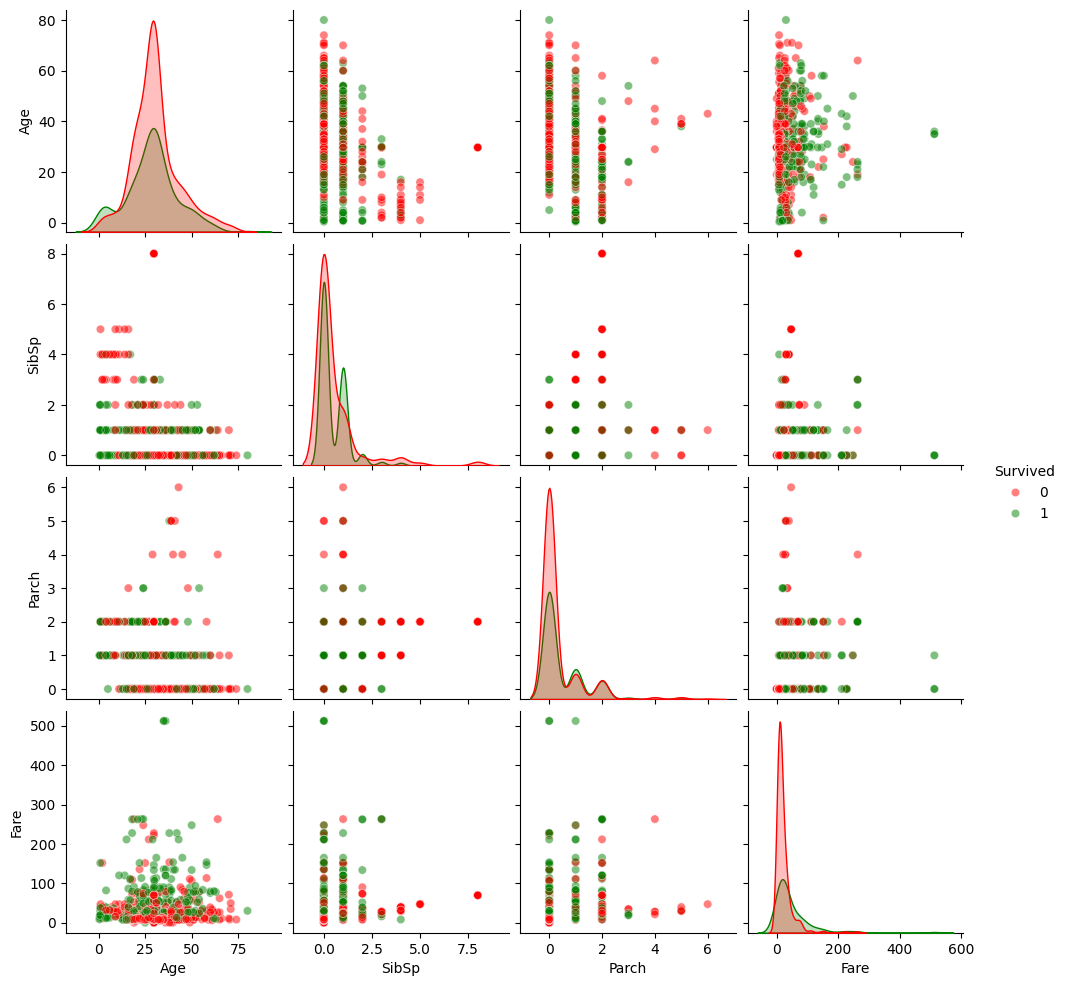

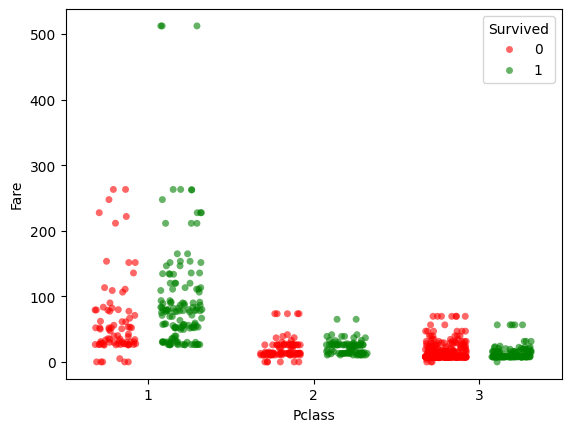

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df,
    vars=['Age', 'SibSp', 'Parch', 'Fare'], 
    hue='Survived', 
    palette={0: 'red', 1: 'green'},
    plot_kws={'alpha': 0.5} 
)
plt.show()

sns.stripplot(
    data=df,
    x='Pclass',
    y='Fare',
    hue='Survived',
    dodge=True,
    jitter=0.25, 
    palette={0: 'red', 1: 'green'},
    alpha=0.6
)
plt.show()



5. Finally, recall the preprocessing we did in the first exercise. What can you say about the effect of the choices that were made to use the mode and mean to impute missing values, instead of, for example, ignoring passengers with missing data?

Using mean/mode is a good choice in this case. It preserves the data and allows further analysis, without introducing much distortion. On the other hand, ignoring the missing data would have possibly biased the analysis.

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | Working with text data 2.0

This exercise is related to the second exercise from last week. Find the saved <span style="font-weight: 500">pos.txt</span> and <span style="font-weight: 500">neg.txt</span> files, or, alternatively, you can find the week 1 example solutions on the MOOC platform after Tuesday.

1. Find the most common words in each file (positive and negative). Examine the results. Do they tend to be general terms relating to the nature of the data? How well do they indicate positive/negative sentiment?

In [34]:
from collections import Counter
import string

def common(filename, n=20):
    with open(filename, 'r', encoding='utf-8') as f:
        text = f.read().lower() 

    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    counter = Counter(words)
    return counter.most_common(n)

g_c = common('neg.txt')
print("Most common words in negative reviews:")
for word, count in g_c:
    print(word, count)

print("\n" + "-"*50 + "\n")

p_c = common('pos.txt')
print("Most common words in positive reviews:")
for word, count in p_c:
    print(word, count)


Most common words in negative reviews:
work 39998
use 37244
fit 31294
product 24394
just 23581
light 22907
like 20685
time 19665
look 18824
instal 18709
did 18447
good 17295
dont 17136
buy 16885
car 16694
return 15227
tri 14957
doe 14201
replac 13509
didnt 13045

--------------------------------------------------

Most common words in positive reviews:
great 435907
work 427780
use 345234
good 291448
fit 273505
instal 229408
product 210085
look 181401
just 180420
like 175725
easi 162864
light 147322
car 147195
price 144891
need 136519
perfect 124405
time 123938
replac 122261
qualiti 119732
nice 119314


2. Compute a [TF/IDF](https://en.wikipedia.org/wiki/Tf–idf) vector for each of the two text files, and make them into a <span style="font-weight: 500">2 x m</span> matrix, where <span style="font-weight: 500">m</span> is the number of unique words in the data. The problem with using the most common words in a review to analyze its contents is that words that are common overall will be common in all reviews (both positive and negative). This means that they probably are not good indicators about the sentiment of a specific review. TF/IDF stands for Term Frequency / Inverse Document Frequency (here the reviews are the documents), and is designed to help by taking into consideration not just the number of times a term occurs (term frequency), but also how many times a word exists in other reviews as well (inverse document frequency). You can use any variant of the formula, as well as off-the-shelf implementations. <span style="font-weight: 500">*Hint: You can use [sklearn](http://scikit-learn.org/).*</span>

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

with open('pos.txt', 'r', encoding='utf-8') as f:
    pos = f.read()

with open('neg.txt', 'r', encoding='utf-8') as f:
    neg = f.read()

documents = [pos, neg] 

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') 

tfidf_matrix = vectorizer.fit_transform(documents)

tfidf_array = tfidf_matrix.toarray()

print(tfidf_array.shape)

print("\nTF-IDF matrix (up till 20):")
print(tfidf_array[:, :20]) 


(2, 235414)

TF-IDF matrix (first 20 words):
[[3.72801156e-04 7.16925301e-05 4.55458426e-05 2.53032459e-06
  1.68688306e-06 0.00000000e+00 1.18542764e-06 1.18542764e-06
  3.55628292e-06 2.37085528e-06 1.18542764e-06 1.18542764e-06
  1.68688306e-06 1.18542764e-06 1.18542764e-06 1.18542764e-06
  1.18542764e-06 1.18542764e-06 2.37085528e-06 9.27785683e-06]
 [2.19820805e-04 1.74340638e-04 6.06402220e-05 7.58002775e-06
  7.58002775e-06 1.06534645e-05 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  7.58002775e-06 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 2.27400833e-05]]


3. List the words with the highest TF/IDF score in each class (positive | negative), and compare them to the most common words. What do you notice? Did TF/IDF work as expected?

In [43]:
import numpy as np

words = vectorizer.get_feature_names_out()

for i, label in enumerate(['Positive', 'Negative']):
    top_indices = np.argsort(tfidf_array[i])[::-1][:10]
    top_words = [words[j] for j in top_indices]
    top_scores = [tfidf_array[i][j] for j in top_indices]
    print(f"\nTop 10 words for {label}:")
    for word, score in zip(top_words, top_scores):
        print(f"{word}: {score:.3f}")



Top 10 words for Positive:
great: 0.368
work: 0.361
use: 0.291
good: 0.246
fit: 0.231
instal: 0.193
product: 0.177
look: 0.153
just: 0.152
like: 0.148

Top 10 words for Negative:
work: 0.303
use: 0.282
fit: 0.237
product: 0.185
just: 0.179
light: 0.174
like: 0.157
time: 0.149
look: 0.143
instal: 0.142


4. Plot the words in each class with their corresponding TF/IDF scores. Note that there will be a lot of words, so you’ll have to think carefully to make your chart clear! If you can’t plot them all, plot a subset – think about how you should choose this subset.

    <span style="font-weight: 500">*Hint: you can use word clouds. But feel free to challenge yourselves to think of any other meaningful way to visualize this information!*</span>

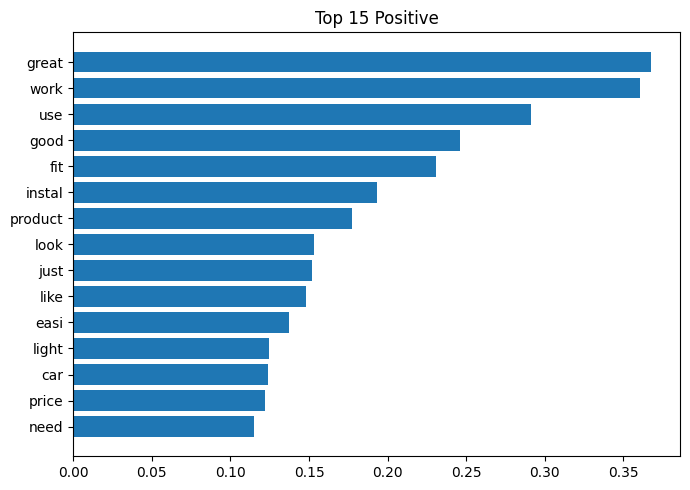

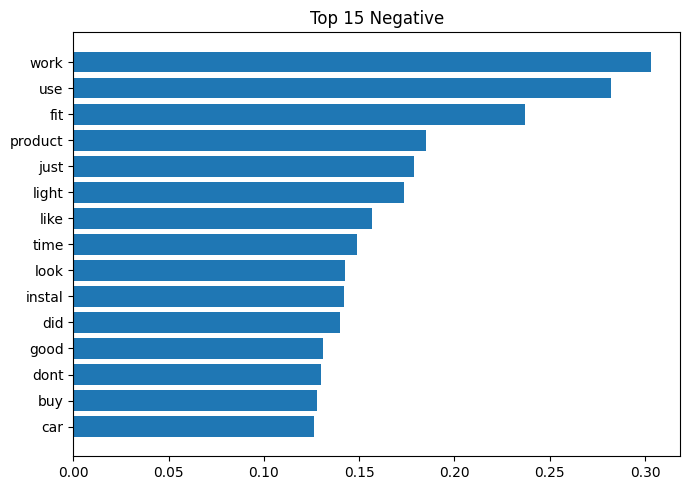

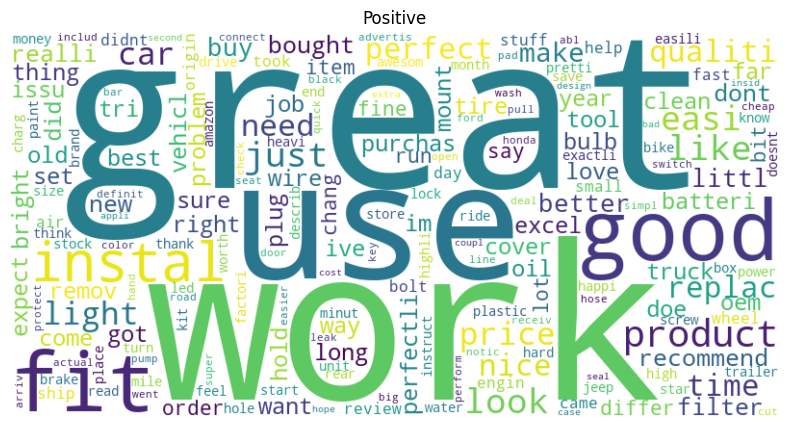

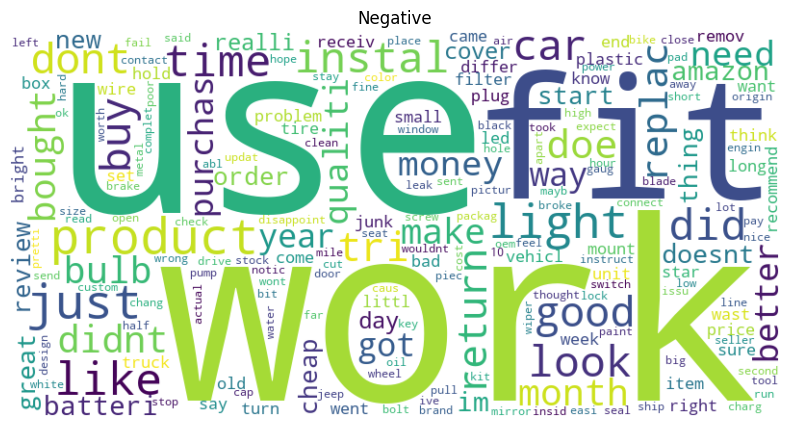

In [47]:
from wordcloud import WordCloud

labels = ['Positive','Negative']

for i,label in enumerate(labels):
    scores = tfidf_array[i]
    idx = np.argsort(scores)[::-1][:15]
    top_w = words[idx]
    top_s = scores[idx]
    plt.figure(figsize=(7,5))
    plt.barh(top_w[::-1], top_s[::-1])
    plt.title(f'Top 15 {label}')
    plt.tight_layout()
    plt.show()

wc_pos = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(words, tfidf_array[0])))
wc_neg = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(zip(words, tfidf_array[1])))

plt.figure(figsize=(10,5)); plt.imshow(wc_pos, interpolation='bilinear'); plt.axis('off'); plt.title('Positive'); plt.show()
plt.figure(figsize=(10,5)); plt.imshow(wc_neg, interpolation='bilinear'); plt.axis('off'); plt.title('Negative'); plt.show()



**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 4 | Junk charts

There’s a thriving community of chart enthusiasts who keep looking for statistical graphics that they find inappropriate, and which they call “junk charts”, and who often also propose ways to improve them.

1. Find at least three statistical visualizations you think are not very good and identify their problems. Copying examples from various junk chart websites is not accepted – you should find your own junk charts, out in the wild. You should be able to find good (or rather, bad) examples quite easily since a significant fraction of charts can have at least *some* issues. The examples you choose should also have different problems, e.g., try to avoid collecting three bar charts, all with problematic axes. Instead, try to find as interesting and diverse examples as you can.

2. Try to produce improved versions of the charts you selected. The data is of course often not available, but perhaps you can try to extract it, at least approximately, from the chart. Or perhaps you can simulate data that looks similar enough to make the point.



**Submit a PDF with all the charts (the ones you found and the ones you produced).**